In [1]:
import snappy
import numpy as np
import matplotlib.pyplot as plt
from invariants import *

# Plot Knot Geography $T(p,q)$
Gordon-Litherland signature bound:
$$
W_\sigma = \left\{
2b \ge \left| e - 2\sigma(K) \right|
\right\}
$$

### TODO
- write a function to draw wedge regions for different invariants in the $e$-$b_1$ plane
- when $\sigma$ and $\upsilon$ are different, draw wedge regions for $T(4,q)$ in the $e$-$b_1$ plane
- For $T(4,5)$ try to find 2 band moves to the unknot ($\gamma_4(T(4,5)) = 2$ so we need exactly two bands) and compute their normal euler number and upsilon to place them in the wedge plot

In [70]:
def plot_sig_bound(K, erange=(-30,30), brange=(0,30)):
    sigma = K.signature()
    ups = upsilon(K)

    int_points = [(e,b) 
                  for e in range(erange[0], erange[1]+1) 
                  for b in range(brange[0], brange[1]+1)]

    realizable_points = [(e,b) for e,b in int_points if 2*b >= abs(e - 2 * sigma)]
    realizable_e = [e for e,_ in realizable_points]
    realizable_b = [b for _,b in realizable_points]

    resolution = 300
    es = np.linspace(erange[0], erange[1], resolution)
    bs = np.linspace(brange[0], brange[1], resolution)
    e,b = np.meshgrid(es, bs)

    fig, ax = plt.subplots()
    ax.imshow(2 * b >= abs(e - 2 * sigma),
              extent=(erange[0],erange[1],brange[0],brange[1]), origin='lower',
              cmap='Greys', alpha=0.3)
    ax.scatter(realizable_e, realizable_b, s=0.5, c='red')

    plt.title(f"signature bound, sig={sigma}")
    plt.xlim(erange[0], erange[1])
    plt.ylim(brange[0], brange[1])
    plt.xlabel(r'$e$')
    plt.ylabel(r'$b$')
    plt.show()

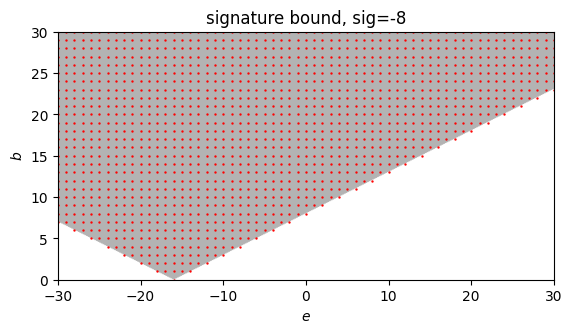

In [71]:
T45 = snappy.Link('T(4,5)')
plot_sig_bound(T45)